# About cross spectrum, coherence, and phase estimation

The goal of this "tutorial" is to write a "physicist-like" summary (main results and key things to remember, no proofs or heavy derivations) for myself, about cross spectra, spectral coherence, and cross-spectral phase. This should typically be read after the similar tutorials about [gaussian stochastic process spectra](https://github.com/jerabaul29/tutorials/blob/main/uncertainty_gaussian_spectrum/uncertainty_gaussian_spectrum.ipynb) and [bicoherence](https://github.com/jerabaul29/tutorials/blob/main/Bicoherence/Bicoherence.ipynb) . As a note, it may have been more logical to look at cross spectrum etc (the present tutorial) before bicoherence, but it just happened I wrote these down in the opposite order :) .

If having more questions, I recommend chatting with an AI - AIs have read a lot about this and with proper user check and critical thinking are very useful. I would have struggled to write this tutorial without AI - the results are typically scattered, hard to find, and either not available online at all or paywalled.

The key references for this tutorial (according to AI):

Goodman, N. R. (1957). "On the joint estimation of the spectra, cospectrum and quadrature spectrum of a two-dimensional stationary Gaussian process." Scientific Paper No. 10, Engineering Statistics Laboratory, New York University.

Carter, G. C., Knapp, C. H., & Nuttall, A. H. (1973). "Estimation of the magnitude-squared coherence function via overlapped fast Fourier transform processing." IEEE Transactions on Audio and Electroacoustics.

Koopmans, L. H. (1995). The Spectral Analysis of Time Series. Academic Press.

Nuttall, A. H. (1971). "Spectral estimation by means of overlapped FFT processing of windowed data." Naval Underwater Systems Center Report.

Bendat, J. S. and Piersol, A. G. (2000). Random Data: Analysis and Measurement Procedures (3rd ed.). Wiley.

Carter, G. C. (1987). "Coherence and time delay estimation." Proceedings of the IEEE, 75(2), 236-255.

## A bit of context about cross spectrum, coherence, and phase estimation for stochastic gaussian processes

In this tutorial, we consider stochastic gaussian processes. Typically, the underlying process is unknown, and can only be observed through some individual realization of the process, typically a timeseries (for example, a wave-in-ice vertical acceleration time series as I will use in the following in my work [arXiv:2507.19034](https://arxiv.org/pdf/2507.19034) ; but any other kind of data following a similar gaussian process will be described by the same laws).

In this tutorial, we focus on the cross spectral density and the coherence and phase estimation that come out of it.

Formally and "abstractly", stochastic gaussian processes are defined from their underlying (usually not observable and hidden) self and cross correlation functions. In the case of interest here (cross correlation), the formal definition of the cross spectral density is as the Fourier transform of the cross-correlation function $R_{XY}(\tau)$ between two stochastic gaussian processes $X$ and $Y$:

$S_{XY}(f) = \int_{-\infty}^{\infty} R_{XY} (\tau) e^{-j 2 \pi f \tau} d \tau$,

where $R_{XY}(\tau) = E[X(t) Y(t + \tau)]$, $\tau$ the time lag. The auto-spectra $S_{XX}(f)$ and $S_{YY}(f)$ are defined analogously from $R_{XX}$ and $R_{YY}$. The true (unsquared) coherence is

$\gamma(f) = \frac{|S_{XY}(f)|}{\sqrt{S_{XX}(f) S_{YY}(f)}}$,

and the true magnitude-squared coherence (MSC) is $\gamma^2(f)$.

In practical, discrete terms, the canonical estimator for $S_{XY}$ is:

$P_{xy}(f) = \left\langle FFT_x^*(f) FFT_y(f) \right\rangle$,

where $\left\langle . \right\rangle$ means "averaging over segments", $x(t)$ and $y(t)$ are the synchronized discrete real world realizations of $X$ and $Y$, and $FFT_x$ and $FFT_y$ their respective discrete Fourier transforms (DFTs). Note that $P_{xy}$ is an array of complex values and has all the usual 2-sided vs 1-sided and conventions caveats that are usual of DFTs (see the tutorial about the power spectrum of gaussian stochastic processes linked above). $P_{xx}$ and $P_{yy}$ are the corresponding (real-valued) auto-spectral estimators, obtained the same way.

Given this, one can define the coherence as:

$C_{xy}(f) = \frac{|P_{xy}(f)|^2}{P_{xx}(f) P_{yy}(f)}$ .

Observe that modulus is taken (these are generally complex values), and that the order of operations is important. In particular for $|P_{xy}(f)|^2$, the average over segments is taken first, then the modulus square is taken. Remember that $P_{xy}$, $P_{xx}$ and $P_{yy}$ are already averaged over segments; taking the modulus per segment before averaging would make $C_{xy}$ identically 1.

Note that $C_{xy}(f)$ as defined here is the *magnitude-squared coherence* (MSC): it is the estimator of the squared true coherence $\gamma^2(f)$, not of $\gamma(f)$ itself. This distinction matters because the distributions below are written in terms of $\gamma$ (or $\gamma^2$). In applications one plugs in $\gamma^2 \leftarrow C_{xy}$ (equivalently $\gamma \leftarrow \sqrt{C_{xy}}$), never $\gamma \leftarrow C_{xy}$.

The consequence is that at a given frequency $f$, if the relative phase between the signals $x$ and $y$ is fully locked across the segments over which the averaging is done *and* their Fourier amplitudes at that frequency are perfectly linearly related, the coherence will be equal to 1 at this frequency. Independent amplitude fluctuations at that frequency still reduce $C_{xy}$ below 1 even with phase lock, and $C_{xy}$ is undefined if either auto-spectrum is zero. If the signals are not phase locked one with another, the coherence estimator will not be exactly 0, but will be biased slightly above 0 (see the bias of the null distribution given below) and should be compared against a significance threshold rather than against exactly 0. This is the same idea as for bicoherence (except bicoherence looked at the coupling between 3 different frequencies, while here we only look at 2).

Naturally, to reduce noise, the usual tricks from the tutorial discussing Welch periodograms apply, i.e. tapering functions, windowing and overlap.

In cases where the coherence is significantly non-zero, it is meaningful to look at the cross-spectrum phase estimator of the true phase $\theta_0(f)=\arg(S_{XY}(f))$:

$\theta_{xy}(f) = \arg{(P_{xy}(f))}$,

where $\arg$ is the argument or "phase" operator.

Therefore, the coherence and cross-spectrum phase are useful to check if two signals $x$ and $y$ are significantly "phase-locked" over time at a given frequency, and if so what their relative phases are.

## Putting error bars on the estimators

As for the previous tutorials, $C_{xy}(f)$ and $\theta_{xy}(f)$ are only estimators for the hidden underlying true value. For stochastic gaussian processes, one can actually compute (either exactly analytically, or asymptotically) the distribution / mean / bias / standard deviation of these estimators relative to the true underlying value. The formulae below assume jointly complex-Gaussian Fourier coefficients (as follows from Gaussian time series and long enough segments) and stationarity.

### Effective number of segments $N_{eff}$

The effective number of segments is computed based on the windowing function and the overlap similarly as for the Welch estimator. It is the $N_{eff}$ that enters both the null and the non-null formulae below.

$N_{eff} = \frac{N}{1 + 2 \sum_{m=1}^{N-1} (1 - \frac{m}{N}) \rho^2(m \times S)}$,

where:

- $N$ is the total number of overlapping segments,
- $\rho(m \times S)$ is the normalized correlation coefficient between 2 segments shifted by $m$ "welch segments" steps (i.e. shifted by $m \times S$ sample points, where $S$ is how many points separate the start of one segment to the start of the next segment: $S=nperseg - noverlap$, with $nperseg$ the number of points per segment and $noverlap$ the number of overlapping points between 2 consecutive segments), which is computed from the windowing function $w$ as:
$\rho(m \times S) = \frac{\sum_n w[n] w[n+m \times S]}{\sum_n w^2[n]}$
(with $w[n+m \times S] = 0$ outside the support of the window).

Note that all the Goodman/Carter distributions and approximations below (the non-null coherence PDF, its mean/bias/std, and the phase-error PDF/std) are derived assuming $N_{eff}$ independent segments. In practice, with overlapped Welch segments, the segments are not truly independent; $N_{eff}$ as computed here is only an approximate correction accounting for this residual correlation, so the resulting significance thresholds and error bars should themselves be treated as approximate, especially for small $N_{eff}$ or heavy overlap.

### Case with underlying coherence truly equal to zero

In this case, $C_{xy}$ follows a beta distribution with parameters $\alpha=1$ and $\beta = N_{eff}-1$, with $N_{eff}$ the effective number of independent segments. This means that the cumulative distribution function (CDF) simplifies as:

$P(C_{xy} <= c) = 1 - (1-c)^{N_{eff}-1}$

The mean (equal to the bias) is $E[C_{xy}] = Bias{(C_{xy})} = 1/N_{eff}$, and the standard deviation (note the distribution is a beta distribution which is skewed, not for example a gaussian) is $\sigma = \frac{1}{N_{eff}} \sqrt{\frac{N_{eff}-1}{N_{eff}+1}} \approx 1 / N_{eff}$ . This means that one needs to be significantly above the bias to ensure that there is true non-zero coherence.

In practice, this null CDF gives a direct way to build a significance threshold: for a chosen confidence level (e.g. 95%), the coherence value $c_{crit}$ that a purely-noise (zero true coherence) signal pair would exceed only 5% of the time is obtained by solving $P(C_{xy} <= c_{crit}) = 0.95$, i.e.:

$c_{crit} = 1 - (1-0.95)^{1/(N_{eff}-1)} = 1 - 0.05^{1/(N_{eff}-1)}$ .

Any estimated coherence value above $c_{crit}$ can then be considered significantly non-zero at the chosen confidence level. This threshold is per frequency: if one scans a full spectrum, a fraction of noise frequencies (about 5% at this 95% level, if bins were independent) will exceed $c_{crit}$ by chance.

In this case, the phase $\theta_{xy}(f)$ is uniformly distributed on the whole phase range (typically depending on the arg function used $[-\pi; \pi[$).

### Case with underlying coherence truly strictly positive (non zero)

When the true underlying coherence is strictly positive, the distributions change. Given an underlying true coherence $\gamma(f)$, the estimator $C_{xy}(f)$ follows a Goodman distribution (transformed hypergeometric function distribution) with probability density function (PDF) $f$:

$f(C_{xy}(f)) = (N_{eff}-1)(1-\gamma(f)^2)^{N_{eff}}(1-C_{xy}(f))^{N_{eff}-2} {}_2F_1(N_{eff},N_{eff};1;\gamma(f)^2 C_{xy}(f))$ ,

where $_2F_1$ is the Gauss hypergeometric function. In real world uses, $\gamma(f)$ is unknown; replace $\gamma^2$ by $C_{xy}$ (or $\gamma$ by $\sqrt{C_{xy}}$) in the formulae.

The mean is approximately:

$E(C_{xy}(f)) = \gamma^2 + \frac{1}{N_{eff}}(1-\gamma^2)^2$, which means the bias is approximately $Bias(C_{xy}(f)) \approx \frac{1}{N_{eff}}(1-\gamma^2)^2$ and has strictly speaking to be compensated for,

and the standard deviation is approximately $\sigma(C_{xy}(f)) \approx \frac{\sqrt{2} \gamma (1-\gamma^2)}{\sqrt{N_{eff}}}$ .

This large-$N_{eff}$ approximation vanishes as $\gamma \to 0$ and must not be used there; the null-distribution $\sigma$ above applies instead. It is meant for $\gamma$ not too small and $N_{eff}$ large.

The phase-error PDF and its large-$N_{eff}$ standard deviation given below are from Carter (1987); the 1973 Carter/Knapp/Nuttall paper only covers the MSC statistics, not the phase.

The phase estimator is unbiased and has a PDF for the phase error $\Delta \theta (f) = \theta_{xy}(f) - \theta_0(f)$ with $\theta_0(f)$ the true underlying phase (Carter 1987; here $\gamma^2$ is the true MSC):

$f(\Delta \theta) = \frac{(1-\gamma^2)^{N_{eff}}}{2\pi} \Big[ {}_2F_1(N_{eff}, 1; 1/2; \gamma^2 \cos^2(\Delta \theta)) + \frac{\Gamma(N_{eff}+1/2)}{\Gamma(N_{eff})} \sqrt{\pi}\, \gamma \cos(\Delta \theta)\, {}_2F_1(N_{eff}+1/2, 3/2; 3/2; \gamma^2 \cos^2(\Delta \theta)) \Big]$ .

The first hypergeometric term alone is even in $\cos(\Delta \theta)$ and would put a spurious peak at $\pm\pi$; the second term removes it. For large $N_{eff}$ this converges to a gaussian.

This is unbiased ($E(\theta_{xy}(f)) = \theta_0(f)$), and has a standard deviation that converges for large enough $N_{eff}$ to:

$\sigma_{\theta}(f) \approx \sqrt{\frac{1-\gamma^2(f)}{2 N_{eff} \gamma^2(f)}}$ (in rads).

So the higher $\gamma$ (estimated by $\sqrt{C_{xy}}$) and the effective number of segments $N_{eff}$, the more accurate the phase estimate. Equivalently, plugging $\gamma^2 \leftarrow C_{xy}$:

$\sigma_{\theta}(f) \approx \sqrt{\frac{1-C_{xy}(f)}{2 N_{eff} C_{xy}(f)}}$ (in rads).

A practical consequence is that, once $\gamma$ is significantly non-zero, one can also build a confidence interval on the estimated phase itself, in the usual gaussian large-$N_{eff}$ approximation: $\theta_0(f) \in [\theta_{xy}(f) - z \sigma_{\theta}(f); \theta_{xy}(f) + z \sigma_{\theta}(f)]$ at confidence level corresponding to $z$ (e.g. $z \approx 1.96$ for 95%), analogously to the significance threshold $c_{crit}$ built above for the coherence.

This Gaussian interval is poor for small $N_{eff}$ or only marginally significant $\gamma$. Near $\pm \pi$ the interval can wrap; treat phase as circular.


## Example: looking at the wave propagation between 2 points on sea ice

These are example data taken from the paper [arXiv:2507.19034](https://arxiv.org/pdf/2507.19034). We only consider a small segment of the data considered there: vertical acceleration from two IMUs on sea ice in Tempelfjorden (segment 2),

- `VN1005`: outer sensor
- `VN1007`: inner sensor
- `VN1002`: another inner sensor, close to the first one

The sensors 2 and 7 are quite close to each other; sensor 5 is quite a bit away from the two others. The outer and inner sensors are about $72\,\mathrm{m}$ apart, the 2 inner sensors about 10 times closer to each other. The idea is that a wave propagating from the outer to the inner sensor shows up as a significant coherence and a cross-spectral phase $\theta(f) \approx k(f)\, d$ (here the alignment angle between the IMU pair and the wave direction is taken to be $0$). From that phase one can read an experimental dispersion relation $k(f)$ and compare it to open-water and elastic-plate theory.

Welch / CSD parameters follow the original analysis (Hann, $n_\mathrm{perseg}=2048$, $90\%$ overlap). Uncertainties use the formulae from above, with $N_\mathrm{eff}$ from the overlap-corrected segment count.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import fsolve


def welch_n_eff(n_total, nperseg, noverlap, window="hann"):
    """Effective number of independent Welch segments (see N_eff above).

    Returns
    -------
    n_eff : float
    n_segments : int
        Raw (correlated) segment count.
    """
    hop = nperseg - noverlap
    if hop <= 0:
        raise ValueError("noverlap must be strictly less than nperseg")
    n_segments = 1 + (n_total - nperseg) // hop
    if n_segments < 2:
        raise ValueError("need at least 2 segments")

    if isinstance(window, str):
        # fftbins=True: periodic window, matching scipy.signal.csd / coherence
        w = signal.get_window(window, nperseg, fftbins=True)
    else:
        w = np.asarray(window, dtype=float)
        if w.size != nperseg:
            raise ValueError("window array must have length nperseg")

    energy = np.sum(w ** 2)
    rho_sum = 0.0
    for m in range(1, n_segments):
        shift = m * hop
        if shift >= nperseg:
            break
        rho_m = np.sum(w[shift:] * w[:-shift]) / energy
        rho_sum += (1.0 - m / n_segments) * rho_m ** 2

    n_eff = n_segments / (1.0 + 2.0 * rho_sum)
    return n_eff, n_segments


def msc_null_c_crit(n_eff, confidence=0.95):
    """Per-frequency MSC significance threshold under true γ = 0."""
    return 1.0 - (1.0 - confidence) ** (1.0 / (n_eff - 1.0))


def msc_std(C, n_eff, c_crit):
    """Std of the MSC estimator C_xy.

    Uses the null beta result below c_crit, and the large-N_eff Goodman
    approximation above, with the plug-in γ ← sqrt(C). The switch at
    c_crit is a practical heuristic (not itself derived above) to avoid
    using the large-N_eff Goodman formula where it is known to be poor,
    i.e. near/below the null threshold.
    """
    C = np.clip(np.asarray(C, dtype=float), 0.0, 1.0)
    sigma_null = (1.0 / n_eff) * np.sqrt((n_eff - 1.0) / (n_eff + 1.0))
    gamma = np.sqrt(C)
    sigma_pos = np.sqrt(2.0) * gamma * (1.0 - C) / np.sqrt(n_eff)
    return np.where(C > c_crit, sigma_pos, sigma_null)


def msc_debias(C, n_eff):
    """Bias-corrected (compensated) MSC estimator.

    Subtracts the approximate bias Bias(C_xy) ≈ (1 - C_xy)^2 / N_eff (plug-in
    γ^2 ← C_xy, see text above) from the raw (uncompensated) C_xy, clipped to
    [0, 1]. Use only as a rough correction: it is derived from the same
    large-N_eff approximation as msc_std's positive branch, so it degrades
    close to/under c_crit, where the null-distribution bias 1/N_eff applies
    instead.
    """
    C = np.clip(np.asarray(C, dtype=float), 0.0, 1.0)
    bias = (1.0 - C) ** 2 / n_eff
    return np.clip(C - bias, 0.0, 1.0)


def phase_std_rad(C, n_eff):
    """Std of the cross-spectrum phase (rad), plug-in γ^2 ← C."""
    C = np.clip(np.asarray(C, dtype=float), 0.0, 1.0)
    out = np.full_like(C, np.nan, dtype=float)
    good = C > 0.0
    out[good] = np.sqrt((1.0 - C[good]) / (2.0 * n_eff * C[good]))
    return out


def unwrap_phase_positive_branch(phase_rad):
    """Unwrap phase, lifting the first sample by 2π if it sits near -π.

    This picks the branch on which k = θ / d is positive for waves travelling
    from the outer IMU toward the inner one (same convention as the original
    analysis).
    """
    phase = np.asarray(phase_rad, dtype=float)
    if phase.size == 0:
        return phase.copy()

    offset = 0.0
    first = float(phase[0])
    if first <= -0.5 * np.pi:
        offset = 2.0 * np.pi
        first = first + offset

    out = [first]
    prev = first
    for p in phase[1:]:
        p = float(p) + offset
        if p - prev <= -np.pi:
            offset += 2.0 * np.pi
            p += 2.0 * np.pi
        elif p - prev >= np.pi:
            offset -= 2.0 * np.pi
            p -= 2.0 * np.pi
        out.append(p)
        prev = p
    return np.asarray(out)


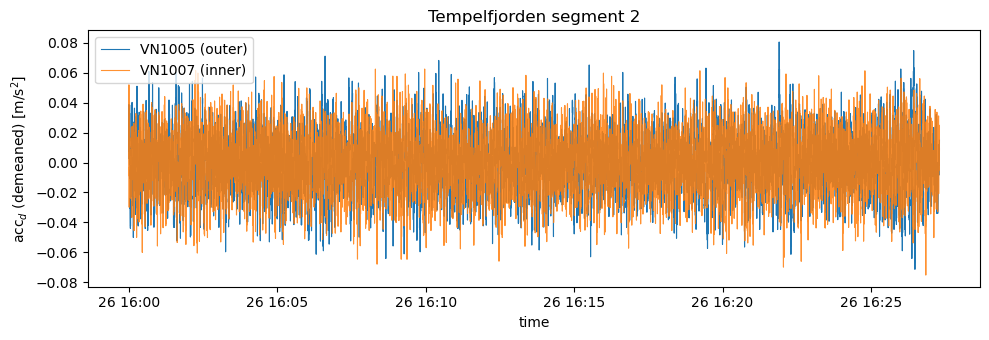

In [2]:
# vertical acceleration, including gravity (~9.8 m/s^2); spectral estimates detrend the mean
df_out = pd.read_csv("segment_2_VN1005.csv")
df_in = pd.read_csv("segment_2_VN1007.csv")

t = pd.to_datetime(df_out["datetime"])
acc_out = df_out["VN1005_acc_d_m/s/s"].to_numpy()
acc_in = df_in["VN1007_acc_d_m/s/s"].to_numpy()
assert len(acc_out) == len(acc_in)

fs = 10.0  # Hz
distance_m = 72.0  # VN1005 (outer) to VN1007 (inner)
angle_buoys_waves_rad = 0.0

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(t, acc_out - acc_out.mean(), label="VN1005 (outer)", lw=0.8)
ax.plot(t, acc_in - acc_in.mean(), label="VN1007 (inner)", lw=0.8, alpha=0.85)
ax.set_ylabel("acc$_d$ (demeaned) [m/s$^2$]")
ax.set_xlabel("time")
ax.set_title("Tempelfjorden segment 2")
ax.legend()
fig.tight_layout()
plt.show()


In [3]:
# same CSD / Welch settings as the original analysis
nperseg = 2048
noverlap = int(0.9 * nperseg)
window = "hann"
detrend = "constant"

n_eff, n_segments = welch_n_eff(len(acc_in), nperseg, noverlap, window=window)
c_crit = msc_null_c_crit(n_eff, confidence=0.95)
z_95 = 1.96

print(f"{n_segments = }")
print(f"{n_eff = :.2f}")
print(f"{c_crit = :.3f}  (95% per-frequency null threshold)")

# csd(inner, outer): if the inner IMU is delayed, arg(P_xy) is positive
f, Pxy = signal.csd(
    acc_in, acc_out,
    fs=fs, window=window, nperseg=nperseg, noverlap=noverlap, detrend=detrend,
)
_, Cxy = signal.coherence(
    acc_in, acc_out,
    fs=fs, window=window, nperseg=nperseg, noverlap=noverlap, detrend=detrend,
)
_, Pxx_in = signal.welch(
    acc_in, fs=fs, window=window, nperseg=nperseg, noverlap=noverlap, detrend=detrend,
)
_, Pxx_out = signal.welch(
    acc_out, fs=fs, window=window, nperseg=nperseg, noverlap=noverlap, detrend=detrend,
)

phase_rad = np.angle(Pxy)
sigma_C = msc_std(Cxy, n_eff, c_crit)
sigma_theta = phase_std_rad(Cxy, n_eff)

# raw (uncompensated) MSC estimator, and the bias-compensated version (msc_debias above)
Cxy_raw = Cxy
Cxy_compensated = msc_debias(Cxy_raw, n_eff)

# same two-tier selection as the original CSD example for this segment:
#   high coherence (swell):     C > 0.25, 0.08 < f < 0.25   → circles
#   low coherence (harmonics):  C > 0.15, 0.08 < f < 0.45   → crosses
# The low-coherence mask is the extra points only (not already in the high set).
# Masking uses the raw (uncompensated) Cxy, matching the original thresholds/analysis.
mask_high = (Cxy_raw > 0.25) & (f > 0.08) & (f < 0.25)
mask_low = (Cxy_raw > 0.15) & (f > 0.08) & (f < 0.45) & ~mask_high

print(f"high-coherence bins (C>0.25, 0.08–0.25 Hz): {int(np.count_nonzero(mask_high))}")
print(f"low-coherence extra bins (C>0.15, 0.08–0.45 Hz): {int(np.count_nonzero(mask_low))}")


n_segments = 70
n_eff = 14.88
c_crit = 0.194  (95% per-frequency null threshold)
high-coherence bins (C>0.25, 0.08–0.25 Hz): 17
low-coherence extra bins (C>0.15, 0.08–0.45 Hz): 10


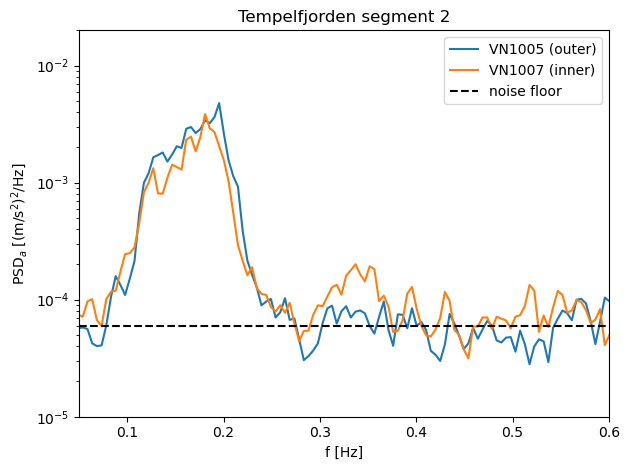

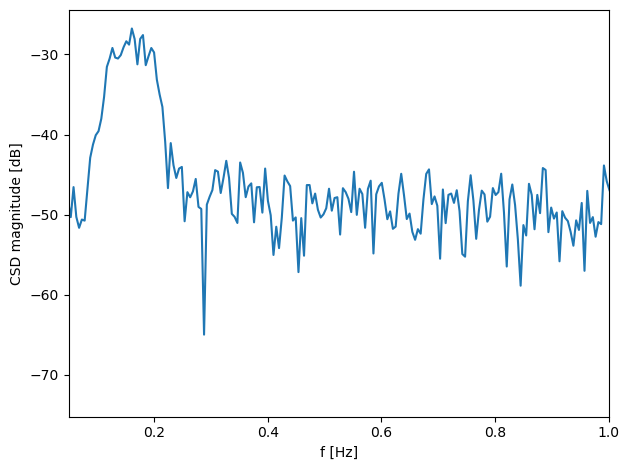

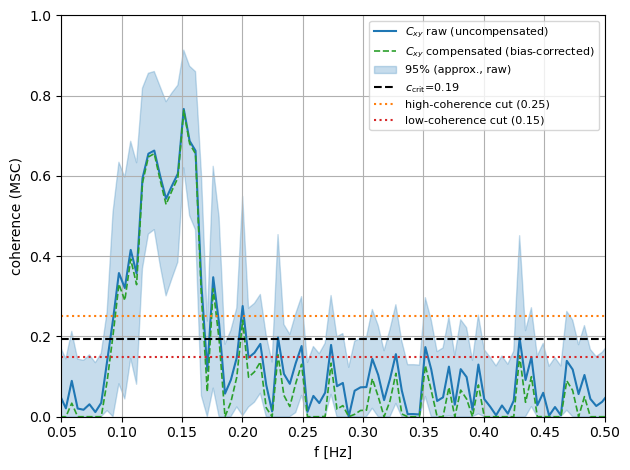

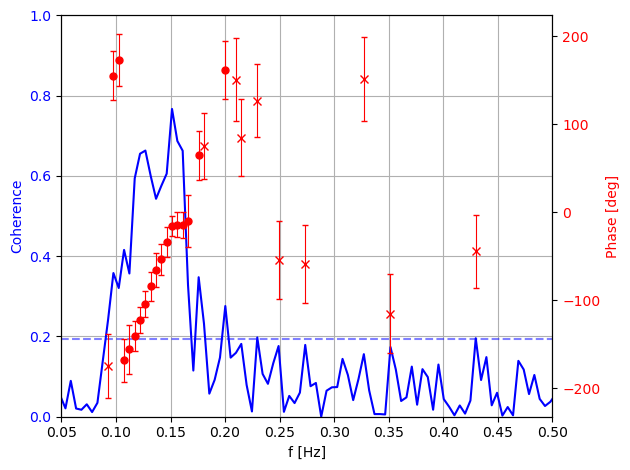

In [4]:
# PSD (acceleration), as in the original look at this segment
fig, ax = plt.subplots()
ax.semilogy(f, Pxx_out, label="VN1005 (outer)")
ax.semilogy(f, Pxx_in, label="VN1007 (inner)")
ax.axhline(6e-5, color="k", ls="--", lw=1.5, label="noise floor")
ax.set_xlim(0.05, 0.6)
ax.set_ylim(1e-5, 2e-2)
ax.set_xlabel("f [Hz]")
ax.set_ylabel(r"PSD$_a$ [(m/s$^2$)$^2$/Hz]")
ax.set_title("Tempelfjorden segment 2")
ax.legend()
fig.tight_layout()
plt.show()

# CSD magnitude
fig, ax = plt.subplots()
ax.plot(f, 10.0 * np.log10(np.abs(Pxy)))
ax.set_xlim(0.05, 1.0)
ax.set_xlabel("f [Hz]")
ax.set_ylabel("CSD magnitude [dB]")
fig.tight_layout()
plt.show()

# coherence with 95% error band and null threshold
# raw (uncompensated) Cxy_raw vs compensated (bias-corrected) Cxy_compensated, see msc_debias above
fig, ax = plt.subplots()
ax.plot(f, Cxy_raw, color="C0", label=r"$C_{xy}$ raw (uncompensated)")
ax.plot(f, Cxy_compensated, color="C2", ls="--", lw=1.2, label=r"$C_{xy}$ compensated (bias-corrected)")
ax.fill_between(
    f,
    np.clip(Cxy_raw - z_95 * sigma_C, 0.0, 1.0),
    np.clip(Cxy_raw + z_95 * sigma_C, 0.0, 1.0),
    color="C0", alpha=0.25, label=r"95% (approx., raw)",
)
ax.axhline(c_crit, color="k", ls="--", label=fr"$c_\mathrm{{crit}}$={c_crit:.2f}")
ax.axhline(0.25, color="C1", ls=":", label="high-coherence cut (0.25)")
ax.axhline(0.15, color="C3", ls=":", label="low-coherence cut (0.15)")
ax.set_xlim(0.05, 0.5)
ax.set_ylim(0.0, 1.0)
ax.set_xlabel("f [Hz]")
ax.set_ylabel("coherence (MSC)")
ax.legend(fontsize=8)
ax.grid(True)
fig.tight_layout()
plt.show()

# twin plot: coherence + phase (circles = high C, crosses = low C)
# coherence trace shown here is the raw (uncompensated) Cxy_raw, matching the masks above
phase_deg = np.rad2deg(phase_rad)
sigma_theta_deg = np.rad2deg(sigma_theta)

fig, ax1 = plt.subplots()
ax1.plot(f, Cxy_raw, "b-")
ax1.axhline(c_crit, color="b", ls="--", alpha=0.5)
ax1.set_xlabel("f [Hz]")
ax1.set_ylabel("Coherence", color="b")
ax1.tick_params(axis="y", labelcolor="b")
ax1.set_xlim(0.05, 0.5)
ax1.set_ylim(0.0, 1.0)

ax2 = ax1.twinx()
ax2.errorbar(
    f[mask_high],
    phase_deg[mask_high],
    yerr=z_95 * sigma_theta_deg[mask_high],
    fmt="o",
    color="r",
    ecolor="r",
    elinewidth=0.8,
    capsize=2,
    ms=5,
    label="high coherence",
)
ax2.errorbar(
    f[mask_low],
    phase_deg[mask_low],
    yerr=z_95 * sigma_theta_deg[mask_low],
    fmt="x",
    color="r",
    ecolor="r",
    elinewidth=0.8,
    capsize=2,
    ms=6,
    label="low coherence",
)
ax2.set_ylabel("Phase [deg]", color="r")
ax2.tick_params(axis="y", labelcolor="r")
ax1.grid(True)
fig.tight_layout()
plt.show()


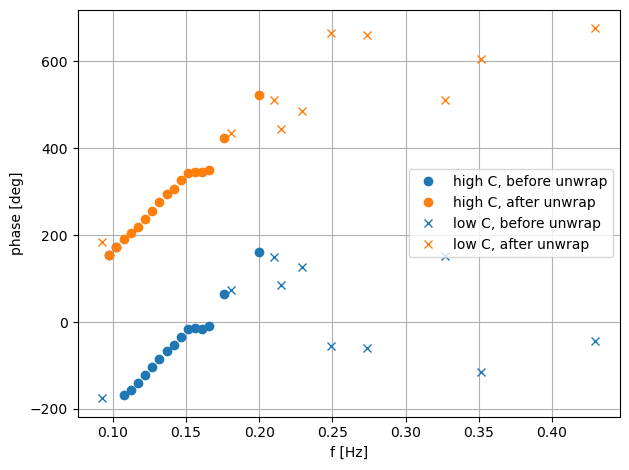

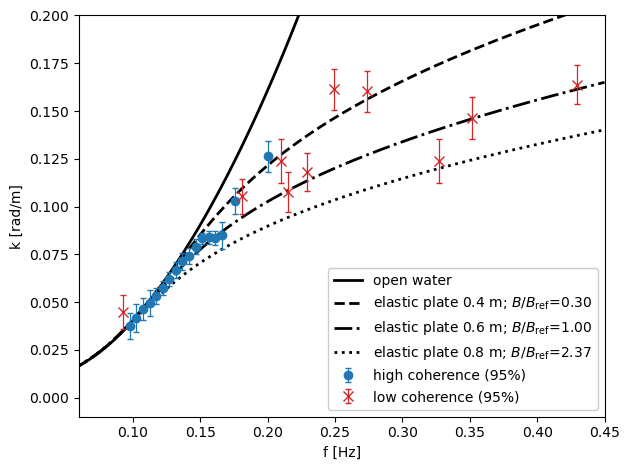

In [5]:
# unwrap high- and low-C bins together in frequency order (same 2π branch),
# then split back into symbols. Unwrapping the sparse low-C set on its own
# misses wraps that only show up on the denser high-C samples.
cos_align = math.cos(angle_buoys_waves_rad)
mask_all = mask_high | mask_low
phase_all = unwrap_phase_positive_branch(phase_rad[mask_all])
k_all = phase_all / (distance_m * cos_align)
sigma_k_all = sigma_theta[mask_all] / (distance_m * cos_align)
is_high = mask_high[mask_all]
is_low = mask_low[mask_all]
f_all = f[mask_all]

f_high, phase_high, k_high, sigma_k_high = f_all[is_high], phase_all[is_high], k_all[is_high], sigma_k_all[is_high]
f_low, phase_low, k_low, sigma_k_low = f_all[is_low], phase_all[is_low], k_all[is_low], sigma_k_all[is_low]

fig, ax = plt.subplots()
ax.plot(f_high, np.rad2deg(phase_rad[mask_high]), "o", color="C0", label="high C, before unwrap")
ax.plot(f_high, np.rad2deg(phase_high), "o", color="C1", label="high C, after unwrap")
ax.plot(f_low, np.rad2deg(phase_rad[mask_low]), "x", color="C0", label="low C, before unwrap")
ax.plot(f_low, np.rad2deg(phase_low), "x", color="C1", label="low C, after unwrap")
ax.set_xlabel("f [Hz]")
ax.set_ylabel("phase [deg]")
ax.legend()
ax.grid(True)
fig.tight_layout()
plt.show()

depth_m = 80.0
g_const = 9.81
f_th = np.linspace(0.05, 0.45, 400)


def k_open_water(freq_hz, depth):
    omega = 2.0 * math.pi * freq_hz

    def residual(k):
        kk = float(np.asarray(k).reshape(-1)[0])
        return omega ** 2 - g_const * kk * math.tanh(kk * depth)

    return float(fsolve(residual, omega ** 2 / g_const)[0])


def k_elastic_plate(freq_hz, depth, h, E=3e9, rho_w=1025.0, nu=0.3, P=0.0, rho_i=920.0):
    omega = 2.0 * math.pi * freq_hz
    D = E * h ** 3 / (rho_w * 12.0 * (1.0 - nu ** 2))
    Q = P * h / rho_w
    M = rho_i * h / rho_w

    def residual(k):
        kk = max(float(np.asarray(k).reshape(-1)[0]), 1e-3)
        return omega ** 2 - (g_const * kk + D * kk ** 5 - Q * kk ** 3) / (1.0 / math.tanh(kk * depth) + kk * M)

    return float(fsolve(residual, omega ** 2 / g_const)[0])


fig, ax = plt.subplots()
ax.plot(f_th, [k_open_water(fi, depth_m) for fi in f_th], color="k", lw=2.0, label="open water")

h_ref = 0.6
D_ref = 3e9 * h_ref ** 3 / (1025.0 * 12.0 * (1.0 - 0.3 ** 2))
for h, ls in zip([0.4, 0.6, 0.8], ["--", "-.", ":"]):
    D = 3e9 * h ** 3 / (1025.0 * 12.0 * (1.0 - 0.3 ** 2))
    ax.plot(
        f_th,
        [k_elastic_plate(fi, depth_m, h) for fi in f_th],
        color="k", lw=2.0, ls=ls,
        label=fr"elastic plate {h} m; $B/B_\mathrm{{ref}}$={D / D_ref:.2f}",
    )

ax.errorbar(
    f_high, k_high, yerr=z_95 * sigma_k_high,
    fmt="o", color="C0", ecolor="C0", elinewidth=0.9, capsize=2,
    label="high coherence (95%)",
)
ax.errorbar(
    f_low, k_low, yerr=z_95 * sigma_k_low,
    fmt="x", color="C3", ecolor="C3", elinewidth=0.9, capsize=2, ms=7,
    label="low coherence (95%)",
)
ax.set_xlabel("f [Hz]")
ax.set_ylabel("k [rad/m]")
ax.set_xlim(0.06, 0.45)
ax.set_ylim(-0.01, 0.2)
ax.legend(framealpha=1.0)
fig.tight_layout()
plt.show()


### Short baseline: VN1002–VN1007

This pair was **not** used for $k(f)$ in the original analysis. VN1002 sits only $\sim 7\,\mathrm{m}$ seaward of VN1007, so at swell frequencies the cross-spectrum phase is only a few tens of degrees. Even though $C_{xy}$ is higher than on the 72 m pair (which shrinks $\sigma_\theta$), $k=\theta/d$ and $\sigma_k=\sigma_\theta/d$ still blow up because $d$ is $\sim 10\times$ smaller — the large error bars are mostly the short baseline, not noisy coherence.

The reason to look anyway is the **high-frequency harmonic**. Both VN1002 and VN1007 have much more high-frequency acceleration power than the outer IMU (VN1005), so the harmonic peak may still give a usable $k(f)$ where the 5–7 baseline is noisy / low-coherence. Circles: swell, $C_{xy}>0.4$. Crosses: extra bins with $C_{xy}>0.15$ up to $0.45\,\mathrm{Hz}$ (the harmonic). Swell $k$ on this short baseline is not trusted (large $\sigma_k$); the useful part is the harmonic-band crosses.


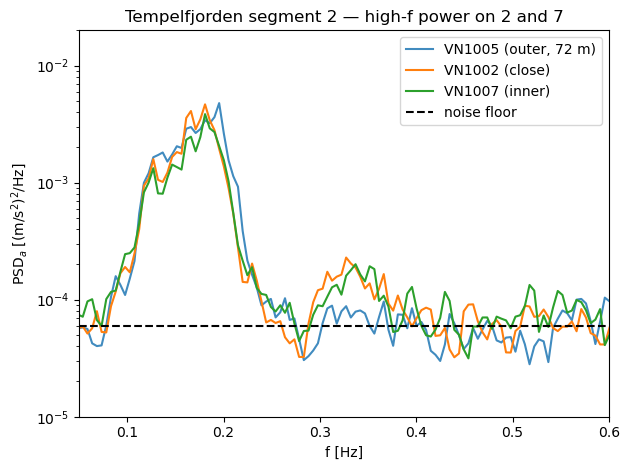

2–7 high-C swell bins (C>0.4, 0.08–0.25 Hz): 28
2–7 extra bins (C>0.15, 0.08–0.45 Hz): 17
swell mean σ_k  5–7 (d=72 m): 0.0026 rad/m;  2–7 (d=7 m): 0.0135 rad/m


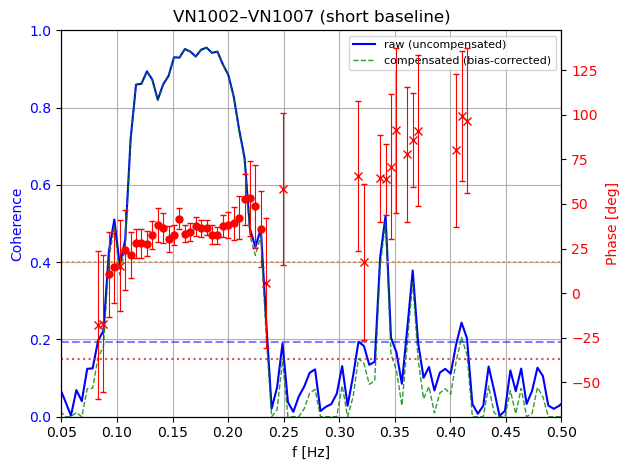

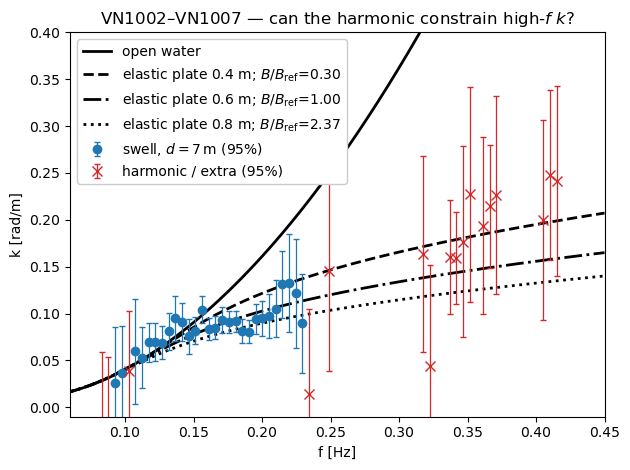

In [6]:
# VN1002 (close, seaward of 7) vs VN1007 (inner). Same Welch / CSD settings as above.
df_2 = pd.read_csv("segment_2_VN1002.csv")
acc_2 = df_2["VN1002_acc_d_m/s/s"].to_numpy()
assert len(acc_2) == len(acc_in)

distance_27 = 7.0  # m; too short to trust swell k, but θ is larger at the harmonic

_, Pxx_2 = signal.welch(
    acc_2, fs=fs, window=window, nperseg=nperseg, noverlap=noverlap, detrend=detrend,
)

# PSD: 2 and 7 keep more high-frequency energy than the outer IMU 5
fig, ax = plt.subplots()
ax.semilogy(f, Pxx_out, label="VN1005 (outer, 72 m)", alpha=0.85)
ax.semilogy(f, Pxx_2, label="VN1002 (close)")
ax.semilogy(f, Pxx_in, label="VN1007 (inner)")
ax.axhline(6e-5, color="k", ls="--", lw=1.5, label="noise floor")
ax.set_xlim(0.05, 0.6)
ax.set_ylim(1e-5, 2e-2)
ax.set_xlabel("f [Hz]")
ax.set_ylabel(r"PSD$_a$ [(m/s$^2$)$^2$/Hz]")
ax.set_title("Tempelfjorden segment 2 — high-f power on 2 and 7")
ax.legend()
fig.tight_layout()
plt.show()

f_27, Pxy_27 = signal.csd(
    acc_in, acc_2,
    fs=fs, window=window, nperseg=nperseg, noverlap=noverlap, detrend=detrend,
)
_, Cxy_27 = signal.coherence(
    acc_in, acc_2,
    fs=fs, window=window, nperseg=nperseg, noverlap=noverlap, detrend=detrend,
)
phase_27 = np.angle(Pxy_27)
sigma_C_27 = msc_std(Cxy_27, n_eff, c_crit)
sigma_theta_27 = phase_std_rad(Cxy_27, n_eff)

# raw (uncompensated) MSC estimator, and the bias-compensated version (msc_debias above)
Cxy_27_raw = Cxy_27
Cxy_27_compensated = msc_debias(Cxy_27_raw, n_eff)

# high C in the swell band vs extra (mostly harmonic) bins
# masking uses the raw (uncompensated) Cxy_27, matching the original thresholds/analysis
mask_high_27 = (Cxy_27_raw > 0.4) & (f_27 > 0.08) & (f_27 < 0.25)
mask_low_27 = (Cxy_27_raw > 0.15) & (f_27 > 0.08) & (f_27 < 0.45) & ~mask_high_27
print(f"2–7 high-C swell bins (C>0.4, 0.08–0.25 Hz): {int(np.count_nonzero(mask_high_27))}")
print(f"2–7 extra bins (C>0.15, 0.08–0.45 Hz): {int(np.count_nonzero(mask_low_27))}")

mask_all_27 = mask_high_27 | mask_low_27
phase_all_27 = unwrap_phase_positive_branch(phase_27[mask_all_27])
f_all_27 = f_27[mask_all_27]
is_high_27 = mask_high_27[mask_all_27]
is_low_27 = mask_low_27[mask_all_27]
k_all_27 = phase_all_27 / distance_27
sigma_k_all_27 = sigma_theta_27[mask_all_27] / distance_27
f_high_27, k_high_27, sk_high_27 = f_all_27[is_high_27], k_all_27[is_high_27], sigma_k_all_27[is_high_27]

# σ_k = σ_θ / d : higher C shrinks σ_θ, but the 10× shorter d dominates
print(
    f"swell mean σ_k  5–7 (d={distance_m:.0f} m): {np.nanmean(sigma_k_high):.4f} rad/m;  "
    f"2–7 (d={distance_27:.0f} m): {np.nanmean(sk_high_27):.4f} rad/m"
)
f_low_27, k_low_27, sk_low_27 = f_all_27[is_low_27], k_all_27[is_low_27], sigma_k_all_27[is_low_27]

fig, ax1 = plt.subplots()
# coherence trace shown here is the raw (uncompensated) Cxy_27_raw, matching the masks above
ax1.plot(f_27, Cxy_27_raw, "b-", label="raw (uncompensated)")
ax1.plot(f_27, Cxy_27_compensated, "g--", lw=1.0, alpha=0.8, label="compensated (bias-corrected)")
ax1.axhline(c_crit, color="b", ls="--", alpha=0.5)
ax1.axhline(0.4, color="C1", ls=":", alpha=0.8)
ax1.axhline(0.15, color="C3", ls=":", alpha=0.8)
ax1.set_xlabel("f [Hz]")
ax1.set_ylabel("Coherence", color="b")
ax1.tick_params(axis="y", labelcolor="b")
ax1.set_xlim(0.05, 0.5)
ax1.set_ylim(0.0, 1.0)
ax1.legend(fontsize=8, loc="upper right")
ax2 = ax1.twinx()
ax2.errorbar(
    f_27[mask_high_27], np.rad2deg(phase_27[mask_high_27]),
    yerr=z_95 * np.rad2deg(sigma_theta_27[mask_high_27]),
    fmt="o", color="r", ecolor="r", elinewidth=0.8, capsize=2, ms=5,
)
ax2.errorbar(
    f_27[mask_low_27], np.rad2deg(phase_27[mask_low_27]),
    yerr=z_95 * np.rad2deg(sigma_theta_27[mask_low_27]),
    fmt="x", color="r", ecolor="r", elinewidth=0.8, capsize=2, ms=6,
)
ax2.set_ylabel("Phase [deg]", color="r")
ax2.tick_params(axis="y", labelcolor="r")
ax1.grid(True)
ax1.set_title("VN1002–VN1007 (short baseline)")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.plot(f_th, [k_open_water(fi, depth_m) for fi in f_th], color="k", lw=2.0, label="open water")
h_ref = 0.6
D_ref = 3e9 * h_ref ** 3 / (1025.0 * 12.0 * (1.0 - 0.3 ** 2))
for h, ls in zip([0.4, 0.6, 0.8], ["--", "-.", ":"]):
    D = 3e9 * h ** 3 / (1025.0 * 12.0 * (1.0 - 0.3 ** 2))
    ax.plot(
        f_th, [k_elastic_plate(fi, depth_m, h) for fi in f_th],
        color="k", lw=2.0, ls=ls,
        label=fr"elastic plate {h} m; $B/B_\mathrm{{ref}}$={D / D_ref:.2f}",
    )
ax.errorbar(
    f_high_27, k_high_27, yerr=z_95 * sk_high_27,
    fmt="o", color="C0", ecolor="C0", elinewidth=0.9, capsize=2,
    label=fr"swell, $d={distance_27:.0f}\,\mathrm{{m}}$ (95%)",
)
ax.errorbar(
    f_low_27, k_low_27, yerr=z_95 * sk_low_27,
    fmt="x", color="C3", ecolor="C3", elinewidth=0.9, capsize=2, ms=7,
    label="harmonic / extra (95%)",
)
ax.set_xlabel("f [Hz]")
ax.set_ylabel("k [rad/m]")
ax.set_xlim(0.06, 0.45)
ax.set_ylim(-0.01, 0.4)
ax.set_title("VN1002–VN1007 — can the harmonic constrain high-$f$ $k$?")
ax.legend(framealpha=1.0)
fig.tight_layout()
plt.show()


Generally, these results are consistent with the estimate between the sensors far away - the difference is that though the coherence is quite a lot higher, the separation distance is much shorter, so the error bars are actually in the end much larger! But this confirms the results from analyzing the sensors far away, which is a nice confirmation given that the sensors far away had a low coherence in the harmonic peak.

## Bonus: Monte Carlo check of the estimator distributions and uncertainties

Independent Fourier-coefficient rollouts (the exact Goodman/Carter sampling model: $N_\mathrm{eff}$ complex-Gaussian segments), plus a short time-domain analogue of the ice harmonic. We use $N_\mathrm{eff}=15$, close to the Welch value in the example above. Overlap is **not** included here: these checks are for the independent-segment formulae.

$C_{xy}$ estimates the true MSC $\gamma^2$, not $\gamma$. The non-zero checks are therefore parameterized by true $\gamma^2$, and the Fourier model uses $\gamma=\sqrt{\gamma^2}$.

Cases:

1. true $\gamma^2=0$: $C_{xy}\sim\mathrm{Beta}(1,N_\mathrm{eff}-1)$, phase uniform, $c_\mathrm{crit}$
2. true $\gamma^2\in\{0.1,0.5,0.7,0.9\}$: Goodman PDF for $C_{xy}$, bias / $\sigma(C)$, phase error vs Carter PDF and the large-$N$ $\sigma_\theta$
3. scan in $\gamma^2$: where the large-$N$ $\sigma(C)$ formula dies near 0, and $\sigma_\theta$ blows up


In [7]:
from scipy.special import gamma as gamma_fn
from scipy.special import hyp2f1
from scipy.stats import beta as beta_dist

rng = np.random.default_rng(0)
N_EFF_MC = 15
N_MC = 4000
THETA0 = 1.0  # rad
# true MSC values (what C_xy estimates), analogue of b² in the bicoherence MC
G2_EXAMPLES = (0.1, 0.5, 0.7, 0.9)


def sample_msc_phase(n_eff, gamma2, theta0, n_mc, rng):
    """Independent-segment MSC and phase (Goodman/Carter model).

    Parameters
    ----------
    gamma2 : float
        True magnitude-squared coherence γ², not the unsquared γ.
    """
    sh = (n_mc, int(n_eff))
    X = (rng.normal(size=sh) + 1j * rng.normal(size=sh)) / np.sqrt(2.0)
    W = (rng.normal(size=sh) + 1j * rng.normal(size=sh)) / np.sqrt(2.0)
    g2 = float(np.clip(gamma2, 0.0, 1.0))
    g = np.sqrt(g2)
    Y = g * np.exp(1j * theta0) * X + np.sqrt(max(1.0 - g2, 0.0)) * W
    Pxy = np.mean(np.conj(X) * Y, axis=1)
    C = np.abs(Pxy) ** 2 / (np.mean(np.abs(X) ** 2, axis=1) * np.mean(np.abs(Y) ** 2, axis=1))
    return C, np.angle(Pxy)


def goodman_pdf(C, gamma2, n_eff):
    g2 = float(gamma2)
    C = np.clip(np.asarray(C, dtype=float), 1e-12, 1.0 - 1e-12)
    return (n_eff - 1) * (1.0 - g2) ** n_eff * (1.0 - C) ** (n_eff - 2) * hyp2f1(n_eff, n_eff, 1.0, g2 * C)


def carter_phase_pdf(dtheta, gamma2, n_eff):
    """Carter (1987) phase-error PDF. gamma2 is the true MSC γ²."""
    g2 = float(np.clip(gamma2, 0.0, 1.0))
    n = float(n_eff)
    dtheta = np.asarray(dtheta, dtype=float)
    if g2 <= 0.0:
        return np.full_like(dtheta, 1.0 / (2.0 * np.pi), dtype=float)
    c2 = g2 * np.cos(dtheta) ** 2
    a = (1.0 - g2) ** n / (2.0 * np.pi)
    F1 = hyp2f1(n, 1.0, 0.5, c2)
    coef = (gamma_fn(n + 0.5) / gamma_fn(n)) * np.sqrt(np.pi) * np.sqrt(g2) * np.cos(dtheta)
    F2 = hyp2f1(n + 0.5, 1.5, 1.5, c2)
    return a * (F1 + coef * F2)


def phase_error(theta, theta0):
    return np.angle(np.exp(1j * (theta - theta0)))


c_crit_mc = msc_null_c_crit(N_EFF_MC, confidence=0.95)
print(f"{N_EFF_MC = }, {N_MC = }, {c_crit_mc = :.3f}")
print("true MSC grid γ² =", G2_EXAMPLES)


N_EFF_MC = 15, N_MC = 4000, c_crit_mc = 0.193
true MSC grid γ² = (0.1, 0.5, 0.7, 0.9)


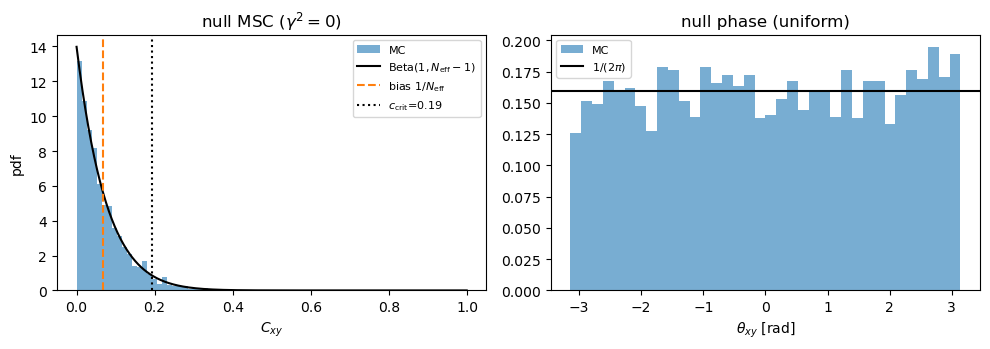

MC mean C = 0.066  (theory 0.067)
MC std  C = 0.062  (theory 0.062)
fraction C > c_crit = 0.045  (should be ~0.05)


In [8]:
# --- 1. true γ² = 0 ---
C0, th0 = sample_msc_phase(N_EFF_MC, 0.0, 0.0, N_MC, rng)
grid = np.linspace(1e-4, 0.999, 400)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].hist(C0, bins=40, density=True, color="C0", alpha=0.6, label="MC")
axes[0].plot(grid, beta_dist.pdf(grid, 1.0, N_EFF_MC - 1), "k-", label=r"Beta$(1,N_\mathrm{eff}-1)$")
axes[0].axvline(1.0 / N_EFF_MC, color="C1", ls="--", label=fr"bias $1/N_\mathrm{{eff}}$")
axes[0].axvline(c_crit_mc, color="k", ls=":", label=fr"$c_\mathrm{{crit}}$={c_crit_mc:.2f}")
axes[0].set_xlabel(r"$C_{xy}$")
axes[0].set_ylabel("pdf")
axes[0].set_title(r"null MSC ($\gamma^2=0$)")
axes[0].legend(fontsize=8)
axes[1].hist(th0, bins=36, density=True, color="C0", alpha=0.6, range=(-np.pi, np.pi), label="MC")
axes[1].axhline(1.0 / (2.0 * np.pi), color="k", label=r"$1/(2\pi)$")
axes[1].set_xlabel(r"$\theta_{xy}$ [rad]")
axes[1].set_title(r"null phase (uniform)")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"MC mean C = {C0.mean():.3f}  (theory {1.0/N_EFF_MC:.3f})")
print(f"MC std  C = {C0.std():.3f}  (theory {(1/N_EFF_MC)*np.sqrt((N_EFF_MC-1)/(N_EFF_MC+1)):.3f})")
print(f"fraction C > c_crit = {np.mean(C0 > c_crit_mc):.3f}  (should be ~0.05)")


**What this shows:** with the true MSC $\gamma^2=0$, the Monte Carlo histogram of $C_{xy}$ matches the null Beta$(1, N_\mathrm{eff}-1)$ PDF, the sample mean/std match the bias $1/N_\mathrm{eff}$ and its std formula, the phase is flat (uniform), and about 5% of draws exceed $c_\mathrm{crit}$ as designed. This directly confirms the "Case with underlying coherence truly equal to zero" section above: even with no true coupling, $C_{xy}$ is biased upward and a significance threshold (not zero) is the right null-hypothesis test.

    γ²   E[C] MC   theory   σ(C) MC   theory   σ(Δθ) MC Carter/G  note
   0.1     0.155    0.154     0.106    0.104      0.689    0.548  below c_crit
       plug-in σ_θ from C: 0.626 vs true 0.548
   0.5     0.518    0.517     0.125    0.129      0.191    0.183  
       plug-in σ_θ from C: 0.183 vs true 0.183
   0.7     0.707    0.706     0.092    0.092      0.127    0.120  
       plug-in σ_θ from C: 0.118 vs true 0.120
   0.9     0.901    0.901     0.036    0.035      0.063    0.061  
       plug-in σ_θ from C: 0.060 vs true 0.061


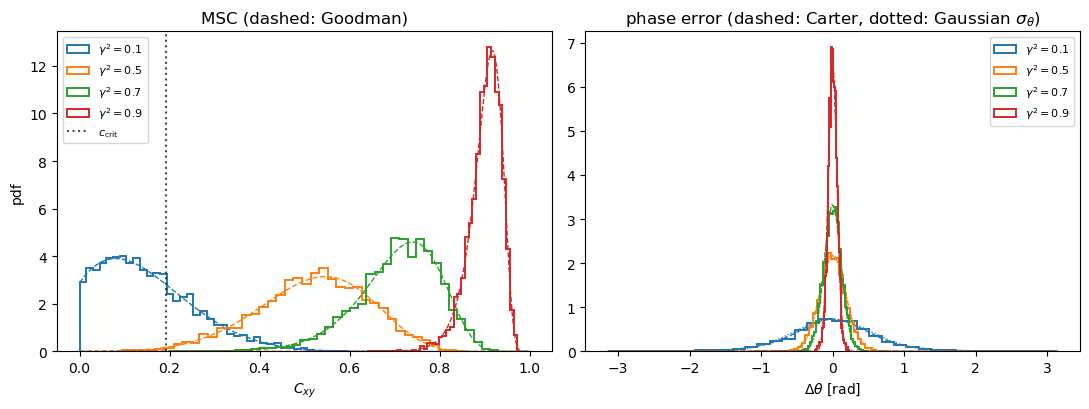

At γ²=0.1, N_eff=15: true MSC is below c_crit, Gaussian σ_θ is too narrow, large-N σ(C) is only fair.


In [9]:
# --- 2. true γ² > 0 (same idea as b² ∈ {0.1, 0.4, 0.6, 0.8} in the bicoherence MC) ---
# C_xy estimates γ². Sampling uses the unsquared γ = sqrt(γ²) in Y = γ e^{iθ} X + ...
xx = np.linspace(-np.pi, np.pi, 400)
colors = {0.1: "C0", 0.5: "C1", 0.7: "C2", 0.9: "C3"}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
print(f"{'γ²':>6}  {'E[C] MC':>8} {'theory':>8}  {'σ(C) MC':>8} {'theory':>8}  {'σ(Δθ) MC':>9} {'Carter/G':>8}  note")
for g2 in G2_EXAMPLES:
    C1, th1 = sample_msc_phase(N_EFF_MC, g2, THETA0, N_MC, rng)
    dth = phase_error(th1, THETA0)
    mean_th = g2 + (1.0 - g2) ** 2 / N_EFF_MC
    sig_C_th = np.sqrt(2.0) * np.sqrt(g2) * (1.0 - g2) / np.sqrt(N_EFF_MC)
    sig_th_th = np.sqrt((1.0 - g2) / (2.0 * N_EFF_MC * g2))
    c = colors[g2]
    axes[0].hist(C1, bins=40, density=True, histtype="step", color=c, lw=1.4,
                 label=fr"$\gamma^2={g2}$")
    axes[0].plot(grid, goodman_pdf(grid, g2, N_EFF_MC), color=c, ls="--", lw=1.0)
    axes[1].hist(dth, bins=36, density=True, histtype="step", color=c, lw=1.4,
                 label=fr"$\gamma^2={g2}$")
    axes[1].plot(xx, carter_phase_pdf(xx, g2, N_EFF_MC), color=c, ls="--", lw=1.0)
    axes[1].plot(xx, np.exp(-0.5 * (xx / sig_th_th) ** 2) / (sig_th_th * np.sqrt(2 * np.pi)),
                 color=c, ls=":", lw=0.9)
    note = "below c_crit" if g2 < c_crit_mc else ""
    print(
        f"{g2:6.1f}  {C1.mean():8.3f} {mean_th:8.3f}  {C1.std():8.3f} {sig_C_th:8.3f}  "
        f"{dth.std():9.3f} {sig_th_th:8.3f}  {note}"
    )
    print(f"       plug-in σ_θ from C: {np.nanmean(phase_std_rad(C1, N_EFF_MC)):.3f} vs true {sig_th_th:.3f}")

axes[0].axvline(c_crit_mc, color="k", ls=":", alpha=0.7, label=r"$c_\mathrm{crit}$")
axes[0].set_xlabel(r"$C_{xy}$")
axes[0].set_ylabel("pdf")
axes[0].set_title(r"MSC (dashed: Goodman)")
axes[0].legend(fontsize=8)
axes[1].set_xlabel(r"$\Delta\theta$ [rad]")
axes[1].set_title(r"phase error (dashed: Carter, dotted: Gaussian $\sigma_\theta$)")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()
print("At γ²=0.1, N_eff=15: true MSC is below c_crit, Gaussian σ_θ is too narrow, large-N σ(C) is only fair.")


**What this shows:** for strictly positive true $\gamma^2$, the MC histograms of $C_{xy}$ and of the phase error $\Delta\theta$ overlay the Goodman PDF and the Carter (1987) phase PDF respectively, and the printed table confirms the mean/bias, $\sigma(C)$ and $\sigma_\theta$ formulas from the "Case with underlying coherence truly strictly positive" section above. The one deviation, at $\gamma^2=0.1$ (below $c_\mathrm{crit}$ at this $N_\mathrm{eff}$), is expected: the large-$N_\mathrm{eff}$ Gaussian approximation for $\sigma_\theta$ is too narrow there, exactly as the text warns should happen close to/below the null threshold.

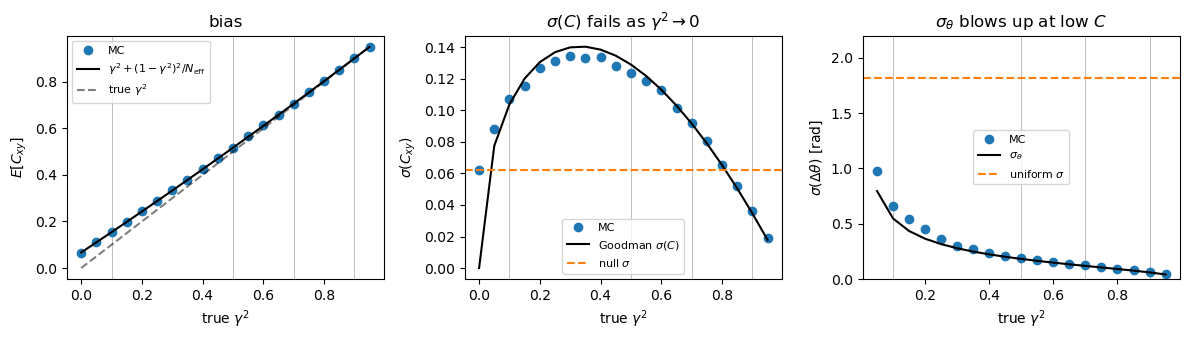

In [10]:
# --- 3. scan γ²: σ(C) formula dies as γ²→0; σ_θ blows up ---
g2s = np.linspace(0.0, 0.95, 20)
mc_mean, mc_std_C, mc_std_th = [], [], []
for g2 in g2s:
    Cg, thg = sample_msc_phase(N_EFF_MC, g2, THETA0, N_MC, rng)
    mc_mean.append(Cg.mean())
    mc_std_C.append(Cg.std())
    mc_std_th.append(phase_error(thg, THETA0).std())
mc_mean, mc_std_C, mc_std_th = map(np.array, (mc_mean, mc_std_C, mc_std_th))

th_mean = g2s + (1.0 - g2s) ** 2 / N_EFF_MC
th_std_C = np.sqrt(2.0) * np.sqrt(g2s) * (1.0 - g2s) / np.sqrt(N_EFF_MC)
th_std_C_null = (1.0 / N_EFF_MC) * np.sqrt((N_EFF_MC - 1.0) / (N_EFF_MC + 1.0))
th_std_th = np.full_like(g2s, np.nan)
good = g2s > 1e-6
th_std_th[good] = np.sqrt((1.0 - g2s[good]) / (2.0 * N_EFF_MC * g2s[good]))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].plot(g2s, mc_mean, "o", label="MC")
axes[0].plot(g2s, th_mean, "k-", label=r"$\gamma^2 + (1-\gamma^2)^2/N_\mathrm{eff}$")
axes[0].plot(g2s, g2s, "k--", alpha=0.5, label=r"true $\gamma^2$")
axes[0].set_xlabel(r"true $\gamma^2$")
axes[0].set_ylabel(r"$E[C_{xy}]$")
axes[0].legend(fontsize=8)
axes[0].set_title("bias")

axes[1].plot(g2s, mc_std_C, "o", label="MC")
axes[1].plot(g2s, th_std_C, "k-", label=r"Goodman $\sigma(C)$")
axes[1].axhline(th_std_C_null, color="C1", ls="--", label=r"null $\sigma$")
axes[1].set_xlabel(r"true $\gamma^2$")
axes[1].set_ylabel(r"$\sigma(C_{xy})$")
axes[1].legend(fontsize=8)
axes[1].set_title(r"$\sigma(C)$ fails as $\gamma^2\to 0$")

axes[2].plot(g2s[good], mc_std_th[good], "o", label="MC")
axes[2].plot(g2s[good], th_std_th[good], "k-", label=r"$\sigma_\theta$")
axes[2].axhline(np.pi / np.sqrt(3.0), color="C1", ls="--", label=r"uniform $\sigma$")
axes[2].set_xlabel(r"true $\gamma^2$")
axes[2].set_ylabel(r"$\sigma(\Delta\theta)$ [rad]")
axes[2].set_ylim(0, 2.2)
axes[2].legend(fontsize=8)
axes[2].set_title(r"$\sigma_\theta$ blows up at low $C$")
for ax in axes:
    for g2 in G2_EXAMPLES:
        ax.axvline(g2, color="0.7", lw=0.6, zorder=0)
fig.tight_layout()
plt.show()


**What this shows:** scanning true $\gamma^2$ from 0 to just under 1 traces out, in one figure, the transition between the two regimes described above. The bias $E[C_{xy}]-\gamma^2$ shrinks as $\gamma^2\to 1$ but never vanishes (left panel); the large-$N_\mathrm{eff}$ Goodman $\sigma(C)$ formula (middle panel) correctly tracks the MC points away from $\gamma^2=0$ but wrongly goes to zero right at $\gamma^2=0$, where the null $\sigma=1/N_\mathrm{eff}\sqrt{(N_\mathrm{eff}-1)/(N_\mathrm{eff}+1)}$ (orange dashed) should be used instead; and the phase std $\sigma_\theta$ (right panel) diverges as $\gamma^2\to 0$, saturating at the uniform-phase std $\pi/\sqrt{3}$, which is why a coherence estimate must first clear $c_\mathrm{crit}$ before its phase is trusted.